In [7]:
%load_ext autoreload
%autoreload 2

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd

from pyprojroot import here

# Ajout de la racine au sys.path pour rendre les dossiers importables
root_dir = here()
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

from building_perceptron.data import fetch_and_save_dataset

Note : on peut télécharger le fichier à l'adresse 
https://drive.google.com/file/d/1itXdRo4WJuhqCjtVX4WGvT327WWp4LB7/view?usp=sharing

In [2]:
# Load Data
output_dir = Path(root_dir) / "data" / "raw_data"
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / "bcw_data.csv"

df = pd.read_csv(output_path, encoding='ascii')

In [3]:
print(f"Doublons dans la colonne 'id': {df['id'].duplicated().sum()}")

Doublons dans la colonne 'id': 0


In [4]:
df = pd.read_csv(output_path, index_col=['id'])

In [5]:
df.head(1)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
id,,,,,,,,,,,,,,,,,,,,,
842302,M,17.99,10.38,122.8,1001.0,0.1184,0.2776,0.3001,0.1471,0.2419,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189,NaN


# EDA

In [6]:
import numpy as np
import pandas as pd
# from eda_utils import *

## Encodage, Doublons, colonnes vides

### 1. Encodage
On vérifie l'encodage au tout début d'une EDA pour éviter de charger de la donnée corrompue sans s'en rendre compte.
- Si on essaie de lire un fichier encodé en latin-1 ou cp1252 en lui imposant du utf-8, Python plante immédiatement lors du pd.read_csv().
- Parfois, le fichier s'ouvre sans erreur, mais les caractères sont mal interprétés : Montréal devient MontrÃ©al

In [7]:
import unicodedata
import chardet

with open(output_path, 'rb') as file :
    encodage = chardet.detect(file.read(10000))

print(encodage)

{'encoding': 'ascii', 'confidence': 1.0, 'language': 'eo', 'mime_type': 'text/plain'}


### 

### Analyse des doublons

In [8]:
cols_sans_id = [col for col in df.columns if col != 'id']
nb_doublons = df.duplicated(subset=cols_sans_id).sum()

if nb_doublons == 0:
    print("Aucun doublon trouvé dans le DataFrame.")
else :
    print(f"Nombre de doublons trouvés : {nb_doublons}\nAppelez la fonction duplicate_rows()")

Aucun doublon trouvé dans le DataFrame.


In [ ]:
# Nombre total de lignes en double
# df.duplicated().sum()

# Afficher toutes les lignes impliquées dans un doublon
# df[df.duplicated(keep=False)].sort_values(by=list(df.columns))

# Doublons basés sur une ou plusieurs colonnes
# df[df.duplicated(subset=['id_client'], keep=False)]

# Garder la première occurrence et supprimer les autres
# df_clean = df.drop_duplicates()

# Ou modifier directement le DataFrame existant
# df.drop_duplicates(inplace=True)

### Colonnes vides

In [9]:
# Remplacer les espaces blancs ou chaînes "null" / "None" par np.nan
df_clean = df.replace(r'^\s*$', np.nan, regex=True).replace(['null', 'None', 'nan', 'N/A'], np.nan)

# Tableau récapitulatif des valeurs manquantes
na_summary = pd.DataFrame({
    'Manquants (count)': df_clean.isna().sum(),
    'Manquants (%)': (df_clean.isna().mean() * 100).round(2)
})

na_summary_filtered = na_summary[na_summary['Manquants (count)'] > 0]
if not na_summary_filtered.empty:
    print("Colonnes avec valeurs manquantes :")
    na_summary[na_summary['Manquants (count)'] > 0].sort_values(by='Manquants (%)', ascending=False)
else:
    print("Aucun colonne vide.")


Colonnes avec valeurs manquantes :


In [10]:
# Colonnes dont toutes les valeurs sont NaN"""
empty_columns = df.columns[df.isna().all()].tolist()

empty_columns

['Unnamed: 32']

In [11]:
df = df.dropna(axis=1, how='all')

In [12]:
# Colonnes contenant des valeurs manquantes explicites : NaN, None, '', 'na', 'null'
missing_vals = {np.nan, None, '', 'na', 'NA', 'null', 'NULL'}
cols = []
for col in df.columns:
    if df[col].isin(missing_vals).any():
        cols.append(col)
cols

[]

### Contrôle et harmonisation des types de données

In [13]:
df.info()
# df.dtypes ou df.info(), puis conversion avec pd.to_datetime(), pd.to_numeric(), ou .astype('category').

<class 'pandas.DataFrame'>
Index: 569 entries, 842302 to 92751
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    str    
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  569 non-nu

### Analyse de la cardinalité et cohérence du texte

In [14]:
# Identifier le nombre de valeurs uniques 
# df.nunique()

# df['colonne'].value_counts()
# df['colonne'].str.strip().str.lower()

## 2. Statistiques descriptives
Les statistiques descriptives dans une EDA permettent de résumer la forme, le centre et la dispersion de tes données pour repérer immédiatement les anomalies, les asymétries ou les valeurs aberrantes.

In [15]:
df.describe(include='all')

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
unique,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,357,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,NaN,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,NaN,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,NaN,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,NaN,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,NaN,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080


1. Mesures de tendance centrale (Où se situe le milieu ?)  
    - Moyenne vs Médiane : La différence entre les deux t'indique la présence d'outliers.  
        Exemple : Si le salaire moyen est de $4\,500\text{ €}$ mais la médiane est à $2\,100\text{ €}$, cela signifie que quelques très hauts salaires tirent la moyenne vers le haut.
    - Mode : La valeur la plus fréquente (très utile pour les variables catégorielles ou discrètes).

2. Mesures de dispersion (Comment les données s'étalent-elles ?)  
    - Écart-type (Standard Deviation) & Variance : Mesurent la distance moyenne des points par rapport à la moyenne.
    - Min et Max : Permettent de vérifier les limites physiques/métier (ex. un âge min de $-5$ ou max de $300$ indique une erreur de saisie).
    - Quartiles ($Q1$, $Q2$/Médiane, $Q3$) & Ecart Interquartile ($IQR = Q3 - Q1$) : L'$IQR$ donne la plage où se trouvent les $50\%$ centraux des données (très robuste aux outliers).

3. Mesures de forme de la distribution  
    - Asymétrie (Skewness) :  
    $>0$ : étalée vers la droite (beaucoup de petites valeurs, quelques très grandes).  
    $<0$ : étalée vers la gauche.
    - Aplatissement (Kurtosis) : Indique si les valeurs sont très concentrées autour de la moyenne ou si les "queues" de distribution sont épaisses (présence fréquente d'outliers).

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, Tuple, Optional, Any, List, Iterable
import math

def plot_numeric_histograms(
    X: pd.DataFrame,
    bins: int = 40,
    n_cols: int = 3,
    figsize_per_col: Tuple[int, int] = (5, 3),
) -> None:
    """
    Affiche les histogrammes de toutes les colonnes numériques.

    Parameters
    ----------
    X : pd.DataFrame
        Données d'entrée.
    bins : int
        Nombre de bins pour les histogrammes.
    n_cols : int
        Nombre de graphes par ligne.
    figsize_per_col : tuple
        Taille d'un subplot (largeur, hauteur).
    """
    num_cols = X.select_dtypes(include=["number"]).columns
    n_plots = len(num_cols)
    if n_plots == 0:
        return
    n_rows = math.ceil(n_plots / n_cols)
    plt.figure(figsize=(n_cols * figsize_per_col[0], n_rows * figsize_per_col[1]))
    for i, col in enumerate(num_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(X[col].dropna(), bins=bins)
        plt.xlabel("")   # masque axe X
        plt.ylabel("")   # masque axe Y
        plt.grid(True, alpha=0.3)
        plt.title(col)
    plt.tight_layout()
    plt.show()

In [17]:
df.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='str')

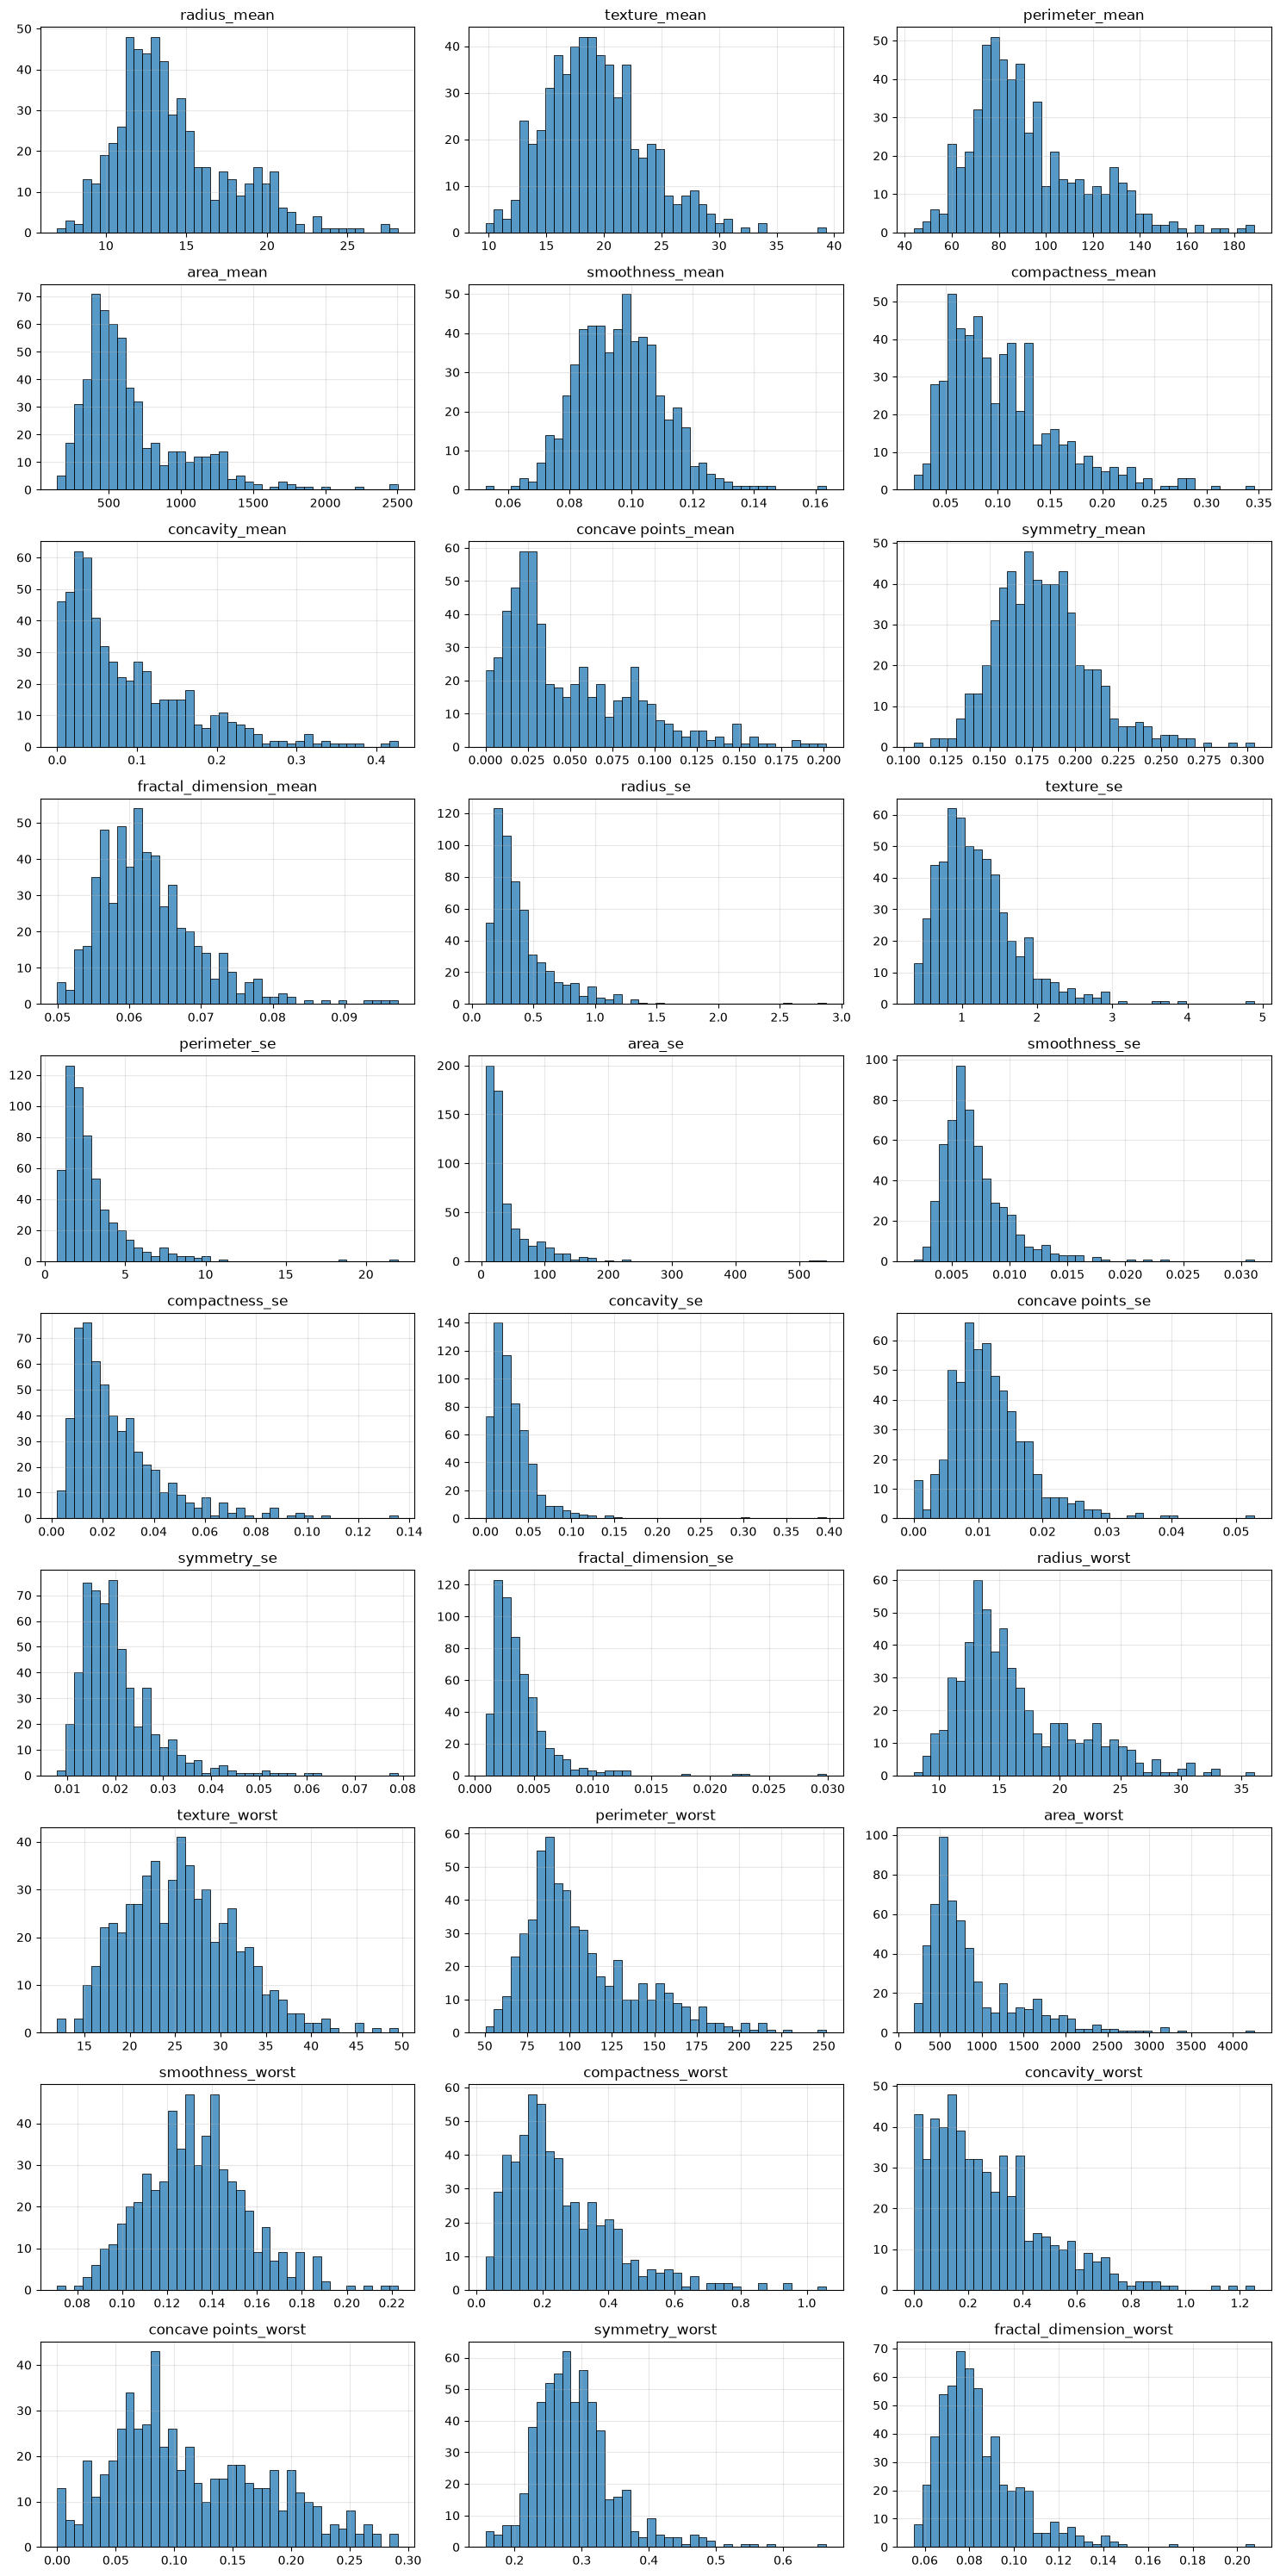

In [16]:
plot_numeric_histograms(df, bins=40, n_cols=3)

### 2a. Bimodularité
On parle de bimodalité lorsqu'une distribution présente deux pics distincts (deux bosses) au lieu d'un seul. Cela indique la présence de deux sous-populations différentes au sein d'une même variable (ici, les tumeurs bénignes et malignes).

La cause de la bimodalité est identifiée :  
- La première bosse (en orange) correspond aux tumeurs bénignes (B), centrées autour d'un rayon de $11\text{–}13$.
- La seconde bosse (en bleu) correspond aux tumeurs malignes (M), étalées au-delà d'un rayon de $15$.
C'est une excellente variable explicative. Les deux distributions sont clairement décalées : radius_mean possède un pouvoir séparateur très fort.  

Zone de décision : La frontière naturelle se situe vers radius_mean = 15. En dessous de $14$, c'est majoritairement bénin ; au-dessus de $16$, c'est presque exclusivement malin. Chevauchement (zone grise entre 13 et 16) : C'est dans cette zone médiane que les deux courbes se croisent. Un Perceptron simple traçant une hyperplan rigide fera quelques erreurs de classification à cet endroit précis.

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

**radius_mean**, **perimeter_mean**, **area_mean**, **concavity_mean**, **compactness_mean**, **concave points_mean** produisent le même exemple de bimodalité : c'est très cohérent, car toutes ces variables mesurent la taille, la forme ou la géométrie globale de la masse cellulaire.

- Colinéarité physique élevée :
Le rayon (radius), le périmètre (perimeter) et la surface (area) sont géométriquement liés. Quand une tumeur grossit, son rayon, son périmètre et sa surface augmentent simultanément. De même pour les points concaves (concave_points), qui augmentent quand la tumeur devient irrégulière.

- Séparation nette Bénin / Malin :
Dans ce dataset (Breast Cancer Wisconsin), les tumeurs malignes sont globalement plus volumineuses et plus déformées que les tumeurs bénignes. C'est pourquoi chacune de ces variables recrée naturellement les deux bosses : une petite pour la classe Bénigne, une grande pour la classe Maligne.

Le Perceptron fonctionnera très bien en gardant toutes les features. Mais on peut réduire la dimensionnalité (avec une PCA ou en supprimant les colonnes extrêmement corrélées) sans perdre en précision.

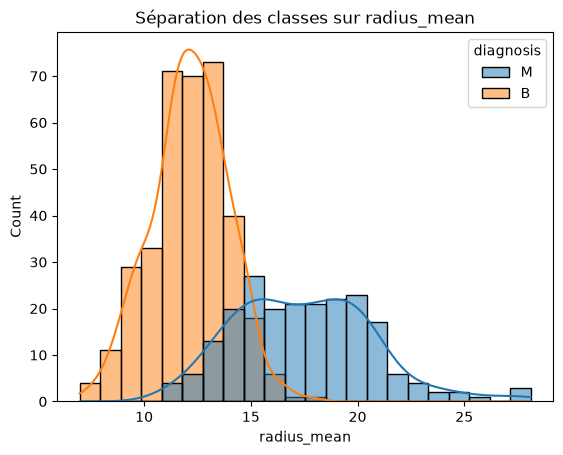

In [19]:
def get_histplot(str):
    sns.histplot(data=df, x=str, hue='diagnosis', kde=True)
    plt.title(f"Séparation des classes sur {str}")
    plt.show()

get_histplot("radius_mean")

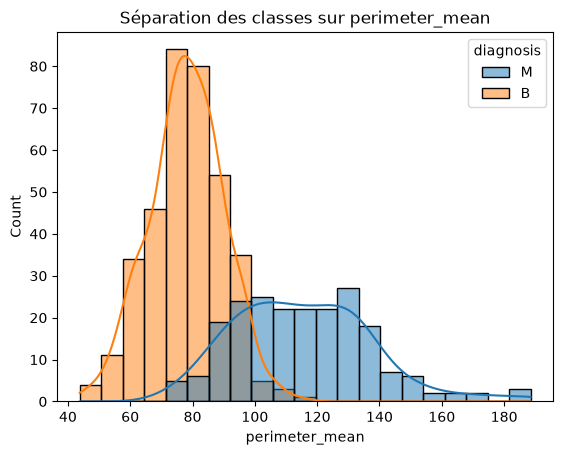

In [20]:
get_histplot("perimeter_mean")

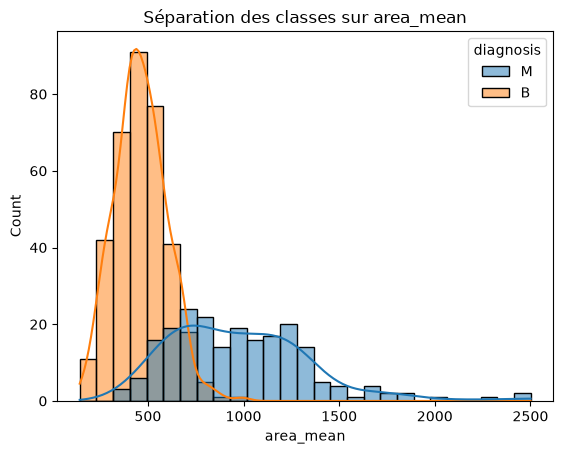

In [19]:
get_histplot("area_mean")

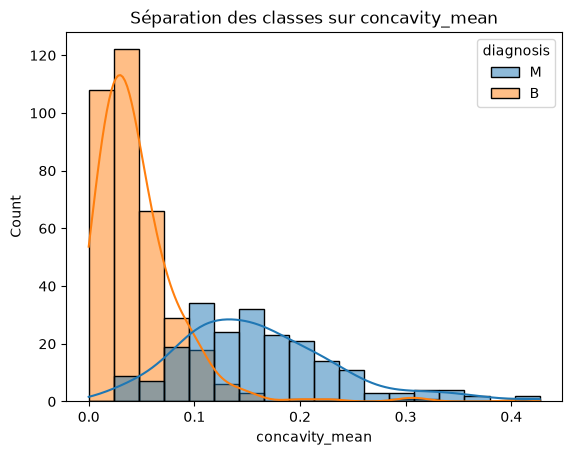

In [21]:
get_histplot("concavity_mean")

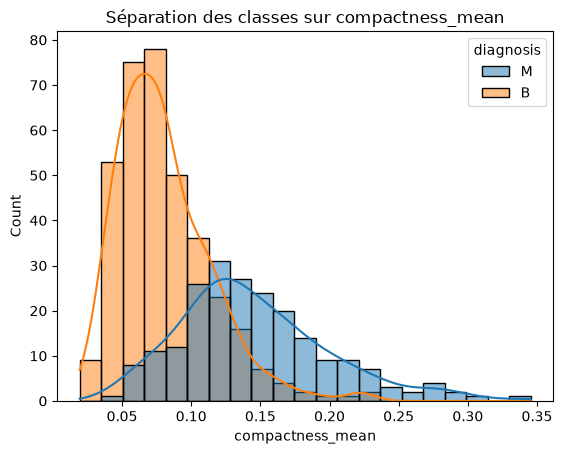

In [22]:
get_histplot("compactness_mean")

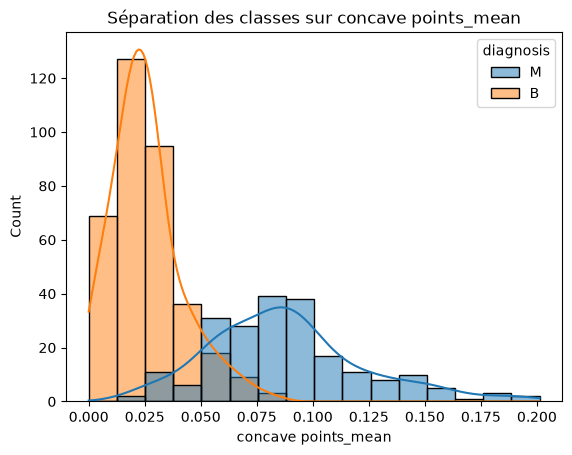

In [22]:
get_histplot("concave points_mean")

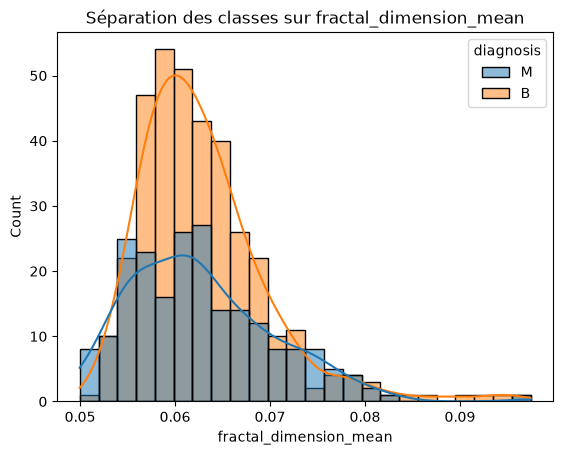

In [23]:
get_histplot("fractal_dimension_mean")

### 2b. Corrélation

1. Encodage de la Target en int

In [23]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])

y = df['diagnosis'].values
X = df.drop(columns=['diagnosis']).reset_index(drop=True)

# Split Train / Test
np.random.seed(42)
indices = np.random.permutation(len(X))
train_size = int(0.8 * len(X))

train_idx, test_idx = indices[:train_size], indices[train_size:]

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train, y_test = y[train_idx], y[test_idx]

In [24]:
from typing import Union

def plot_qualitative(
    X: Union[pd.DataFrame, pd.Series], # Accepte les deux types
    top_n: int = 20,
    n_cols: int = 2,
    figsize_per_col: Tuple[int, int] = (6, 4),
    figsize: Optional[Tuple[int, int]] = None,
    height_per_row: int = 4,
) -> None:
    
    # Conversion si c'est une Series
    if isinstance(X, pd.Series):
        # On donne un nom par défaut si la série n'en a pas
        name = X.name if X.name else "Target"
        X = X.to_frame(name=name)

    """
    Affiche des barplots pour les colonnes qualitatives.

    Parameters
    ----------
    X : pd.DataFrame ou pd.series
        Données d'entrée.
    top_n : int
        Nombre de modalités affichées par colonne.
    n_cols : int
        Nombre de graphes par ligne.
    figsize_per_col : tuple
        Taille d'un subplot (largeur, hauteur).
    """
    cat_cols = X.select_dtypes(include=["object", "category", "string", "bool"]).columns
    n_plots = len(cat_cols)
    if n_plots == 0:
        return

    n_rows = math.ceil(n_plots / n_cols)
    if figsize is None:
        figsize = (n_cols * figsize_per_col[0], n_rows * height_per_row)

    plt.figure(figsize=figsize)
    

    for i, col in enumerate(cat_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        vc = X[col].astype("string").value_counts(dropna=False).head(top_n)
        sns.barplot(x=vc.values, y=vc.index, color="#439cc8")
        plt.xlabel("")
        plt.ylabel("")
        plt.title(col)
        plt.grid(True, axis="x", alpha=0.3)

    plt.tight_layout()
    plt.show()

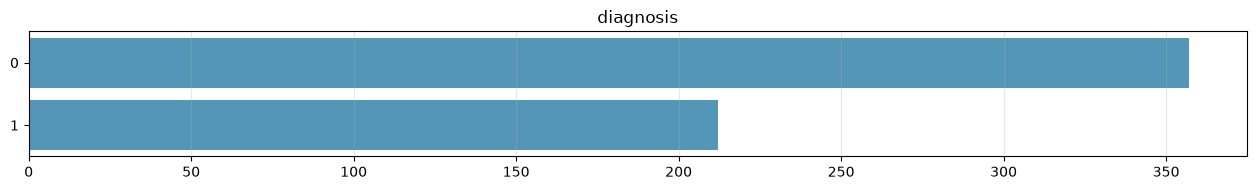

Pourcentage de 1 : 37.26%


In [25]:
plot_qualitative(df["diagnosis"].astype("category"), n_cols=2, figsize=(25, 2))

# Pourcentage de "1" sur l'ensemble des observations
pourcentage_1 = (df["diagnosis"].eq(1).mean()) * 100
print(f"Pourcentage de 1 : {pourcentage_1:.2f}%")

2. Recherche de colinéarité entre features

In [26]:
# Recherche de colinéarité (entre features)
def feature_collinearity(X: pd.DataFrame, threshold: float = 0.8):
    """
    Identifie les paires de features fortement corrélées entre elles (colinéarité).
    
    Parameters
    ----------
    X : pd.DataFrame
        DataFrame contenant les features numériques.
    threshold : float
        Seuil minimum de corrélation absolue à considérer comme colinéaire.
    
    Returns
    -------
    list
        Liste de tuples (feature1, feature2, correlation) triés par corrélation décroissante.
    """
    # Sélectionner uniquement les colonnes numériques
    X_numeric = X.select_dtypes(include=[np.number])
    
    corr_matrix = X_numeric.corr().abs()
    
    # On ne récupère que la partie supérieure de la matrice pour éviter les doublons (A/B et B/A)
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # On filtre par le seuil
    collinear_features = [
        (column, row, upper.loc[row, column]) 
        for column in upper.columns 
        for row in upper.index 
        if upper.loc[row, column] > threshold
    ]
    
    return sorted(collinear_features, key=lambda x: x[2], reverse=True)

In [27]:
collinear_pairs = feature_collinearity( X_train, threshold=0.9)

print("Paires de variables fortement colinéaires :")
for f1, f2, val in collinear_pairs:
    print(f"{f1} <-> {f2} : {val:.4f}")

Paires de variables fortement colinéaires :
perimeter_mean <-> radius_mean : 0.9977
perimeter_worst <-> radius_worst : 0.9935
area_mean <-> radius_mean : 0.9898
area_mean <-> perimeter_mean : 0.9885
area_worst <-> radius_worst : 0.9864
area_worst <-> perimeter_worst : 0.9790
perimeter_worst <-> perimeter_mean : 0.9700
radius_worst <-> radius_mean : 0.9697
radius_worst <-> perimeter_mean : 0.9693
radius_worst <-> area_mean : 0.9677
perimeter_worst <-> radius_mean : 0.9649
perimeter_worst <-> area_mean : 0.9632
perimeter_se <-> radius_se : 0.9613
area_worst <-> area_mean : 0.9600
area_se <-> radius_se : 0.9578
area_worst <-> radius_mean : 0.9417
area_worst <-> perimeter_mean : 0.9413
area_se <-> perimeter_se : 0.9292
concave points_mean <-> concavity_mean : 0.9153
concave points_worst <-> concave points_mean : 0.9146
texture_worst <-> texture_mean : 0.9114


3. Recherche de corrélations avec la Cible
- En croisant la corrélation avec la cible (diagnosis) et la matrice de colinéarité, on a exactement toutes les informations pour faire un choix stratégique.

In [28]:
from typing import Union

# Recherche de corrélations avec la Cible
def target_correlations(X: pd.DataFrame, y: Union[pd.Series, np.ndarray], n_top: int = 10):
    """
    Calcule la corrélation entre toutes les features numériques et la cible.
    Retourne les n premières features les plus corrélées.
    
    La cible doit être numérique (encodée en amont si elle était catégorique).
    
    Parameters
    ----------
    X : pd.DataFrame
        DataFrame contenant les features numériques.
    y : Union[pd.Series, np.ndarray]
        Series ou array représentant la cible encodée (numérique : 0/1, etc).
    n_top : int
        Nombre de top features à retourner.
    
    Returns
    -------
    pd.Series
        Corrélations absolues triées en ordre décroissant.
    """
    # Sélectionner uniquement les colonnes numériques de X
    X_numeric = X.select_dtypes(include=[np.number])
    
    # Créer un DataFrame temporaire avec les features numériques et la cible
    temp_df = X_numeric.copy()
    # Accepter à la fois Series et ndarray
    target_values = y.values if isinstance(y, pd.Series) else y
    temp_df['__target__'] = target_values
    
    # Calculer les corrélations avec la cible
    correlations = temp_df.corr()['__target__'].drop(labels=['__target__']).abs().sort_values(ascending=False)
    
    return correlations.head(n_top)

In [33]:
# Top 10 des variables les plus liées au diagnostic
top_corr = target_correlations(X_train, y_train, n_top=30)
top_corr

perimeter_worst            0.794320
radius_worst               0.789107
concave points_worst       0.786307
concave points_mean        0.773597
area_worst                 0.757021
perimeter_mean             0.754546
radius_mean                0.742527
area_mean                  0.732462
concavity_mean             0.681094
area_se                    0.667774
concavity_worst            0.639282
radius_se                  0.629826
perimeter_se               0.619004
compactness_mean           0.596061
compactness_worst          0.593042
texture_worst              0.462859
texture_mean               0.423741
smoothness_worst           0.420768
symmetry_worst             0.413840
concave points_se          0.397160
smoothness_mean            0.374330
symmetry_mean              0.334290
fractal_dimension_worst    0.312407
compactness_se             0.288361
concavity_se               0.217324
smoothness_se              0.080315
fractal_dimension_se       0.076070
symmetry_se                0

- Quand deux variables sont très corrélées entre elles ($r > 0{,}90$), on garde celle qui a la plus forte corrélation avec le diagnostic et on supprime l'autre.

In [29]:
import pandas as pd
import numpy as np

def remove_collinear_features(df, target_col, threshold=0.90):
    # 1. Calcul des correlations avec la cible
    target_corr = df.corr()[target_col].abs()
    
    # 2. Matrice de correlation entre features
    features = df.drop(columns=[target_col])
    corr_matrix = features.corr().abs()
    
    # 3. Parcourir le triangle supérieur de la matrice
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    to_drop = set()
    for col1 in upper.columns:
        for col2 in upper.index:
            if upper.loc[col2, col1] > threshold:
                # Si correlation > threshold, on compare leur lien avec la cible
                if target_corr[col1] < target_corr[col2]:
                    to_drop.add(col1)
                else:
                    to_drop.add(col2)
                    
    print(f"Nombre de variables supprimées : {len(to_drop)}")
    print("Variables éliminées :", sorted(list(to_drop)))
    
    return df.drop(columns=list(to_drop))

In [30]:
df_cleaned = remove_collinear_features(df, target_col='diagnosis', threshold=0.90)

Nombre de variables supprimées : 10
Variables éliminées : ['area_mean', 'area_se', 'area_worst', 'concave points_mean', 'concavity_mean', 'perimeter_mean', 'perimeter_se', 'radius_mean', 'radius_worst', 'texture_mean']


In [31]:
df_cleaned

,diagnosis,smoothness_mean,compactness_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,smoothness_se,compactness_se,concavity_se,...,symmetry_se,fractal_dimension_se,texture_worst,perimeter_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
id,,,,,,,,,,,,,,,,,,,,,
842302,1,0.11840,0.27760,0.2419,0.07871,1.0950,0.9053,0.006399,0.04904,0.05373,...,0.03003,0.006193,17.33,184.60,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
842517,1,0.08474,0.07864,0.1812,0.05667,0.5435,0.7339,0.005225,0.01308,0.01860,...,0.01389,0.003532,23.41,158.80,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
84300903,1,0.10960,0.15990,0.2069,0.05999,0.7456,0.7869,0.006150,0.04006,0.03832,...,0.02250,0.004571,25.53,152.50,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
84348301,1,0.14250,0.28390,0.2597,0.09744,0.4956,1.1560,0.009110,0.07458,0.05661,...,0.05963,0.009208,26.50,98.87,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
84358402,1,0.10030,0.13280,0.1809,0.05883,0.7572,0.7813,0.011490,0.02461,0.05688,...,0.01756,0.005115,16.67,152.20,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
926424,1,0.11100,0.11590,0.1726,0.05623,1.1760,1.2560,0.010300,0.02891,0.05198,...,0.01114,0.004239,26.40,166.10,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
926682,1,0.09780,0.10340,0.1752,0.05533,0.7655,2.4630,0.005769,0.02423,0.03950,...,0.01898,0.002498,38.25,155.00,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
926954,1,0.08455,0.10230,0.1590,0.05648,0.4564,1.0750,0.005903,0.03731,0.04730,...,0.01318,0.003892,34.12,126.70,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820


- Les variables _se (standard error, soit l'erreur type de la mesure) représentent la variabilité de la mesure pour une même tumeur. Dans le jeu de données Breast Cancer Wisconsin, elles ont un pouvoir prédictif beaucoup plus faible que les variables _mean ou _worst, et apportent souvent plus de bruit que de signal

### 2c. Overlap

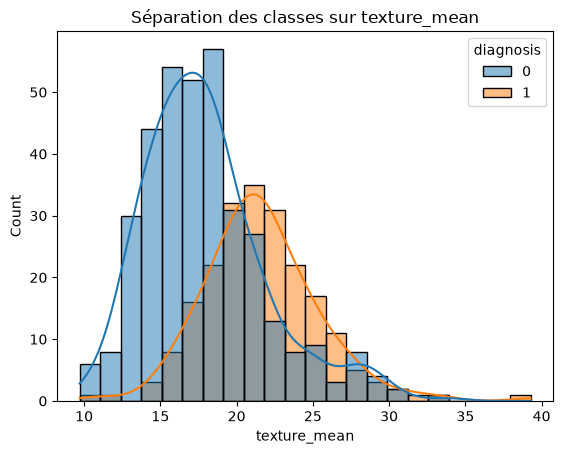

In [33]:
get_histplot("texture_mean")

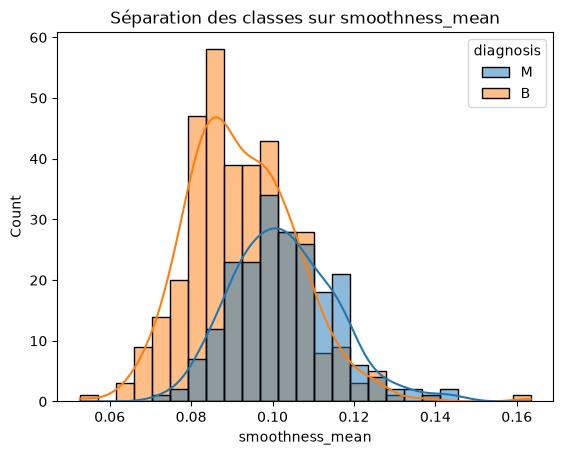

In [95]:
get_histplot("smoothness_mean")

On a un overlap beaucoup plus important : les deux distributions (Bénigne en orange, Maligne en bleu) se croisent largement sur toute la zone entre 15 et 25.

- Un pouvoir séparateur plus faible pris isolément
Contrairement à radius_mean où le creux séparait nettement les deux groupes, texture_mean seule ne permettra pas de trancher facilement : une valeur de 20 peut être aussi bien une tumeur bénigne que maligne.

- Utilisée seule, cette variable générerait beaucoup d'erreurs de classification.

    - Utile en combinaison : Elle apporte quand même une tendance générale (les malignes ont en moyenne une texture plus élevée). Combinée avec radius_mean dans un espace à plusieurs dimensions, elle servira à affiner l'angle de l'hyperplan de séparation.

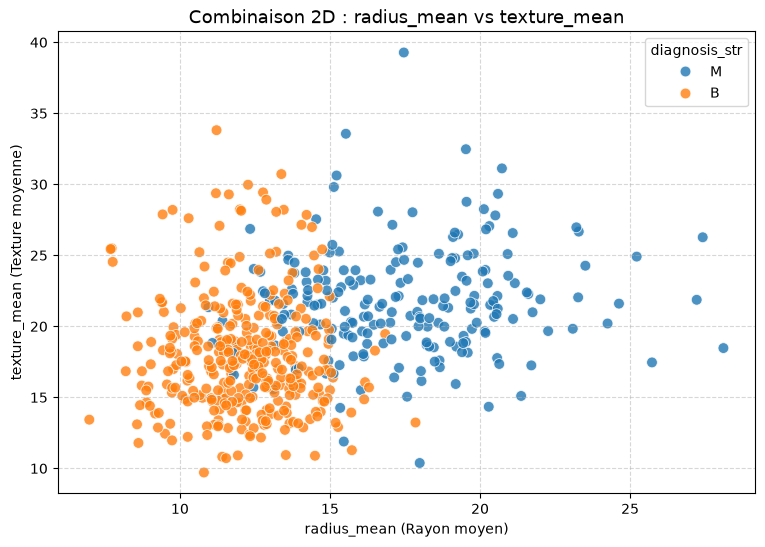

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 6))

# Nuage de points 2D
sns.scatterplot(
    data=df.assign(diagnosis_str=df['diagnosis'].map({0: 'B', 1: 'M'})),
    x='radius_mean',
    y='texture_mean',
    hue='diagnosis_str',
    palette={'B': 'tab:orange', 'M': 'tab:blue'},
    alpha=0.8,
    s=60
)

plt.title("Combinaison 2D : radius_mean vs texture_mean", fontsize=13)
plt.xlabel("radius_mean (Rayon moyen)")
plt.ylabel("texture_mean (Texture moyenne)")
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

Note : Les deux clusters sont bien formés :
- En bas à gauche (orange) : Les tumeurs bénignes (faible rayon, faible/moyenne texture).
- En haut à droite (bleu) : Les tumeurs malignes (rayon élevé, texture moyenne/forte).

Les variables comme symmetry_mean et fractal_dimension_mean se traduisent par deux gaussiennes fortement chevauchées. Pour symmetry_mean, le léger décalage entre les cloches conserve une petite utilité en $N$ dimensions pour affiner l'hyperplan du Perceptron. En revanche, pour fractal_dimension_mean, les deux gaussiennes sont quasiment confondues (corrélation proche de $0$ avec la cible) : elle n'apporte aucun signal exploitable et peut être supprimée."

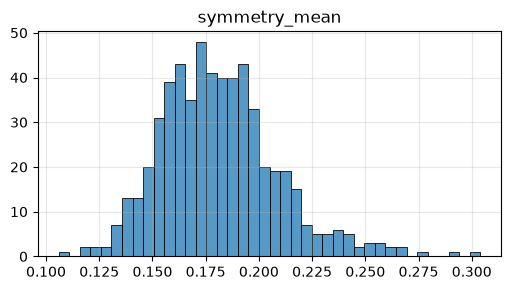

(None, ['fractal_dimension_mean'])

In [36]:
plot_numeric_histograms(df[["symmetry_mean"]], bins=40, n_cols=2), ["fractal_dimension_mean"]

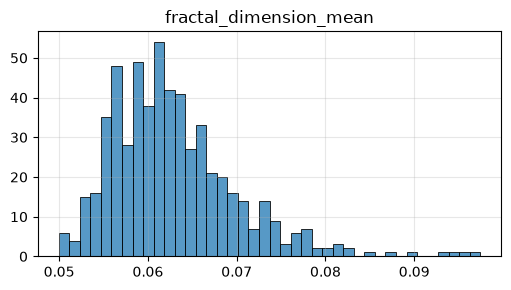

In [37]:
plot_numeric_histograms(df[["fractal_dimension_mean"]], bins=40, n_cols=2)

In [33]:
# Supression des colonnes fractal_dimension_mean
cols_to_drop = [col for col in df_cleaned.columns if col.startswith('fractal_dimension_')]
df_cleaned.drop(columns=cols_to_drop, inplace=True)

- Les variables _se (standard error, soit l'erreur type de la mesure) représentent la variabilité de la mesure pour une même tumeur. Dans le jeu de données Breast Cancer Wisconsin, elles ont un pouvoir prédictif beaucoup plus faible que les variables _mean ou _worst, et apportent souvent plus de bruit que de signal

In [34]:
# Identification et suppression de toutes les colonnes finissant par '_se'
cols_se = [col for col in df_cleaned.columns if col.endswith('_se')]
df_cleaned = df_cleaned.drop(columns=cols_se)

print(f"Colonnes '_se' supprimées ({len(cols_se)}) :", cols_se)

Colonnes '_se' supprimées (7) : ['radius_se', 'texture_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se']


In [35]:
df_cleaned.columns

Index(['diagnosis', 'smoothness_mean', 'compactness_mean', 'symmetry_mean',
       'texture_worst', 'perimeter_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst'],
      dtype='str')

In [36]:
# Sélection des 7 colonnes + diagnosis
cols_to_keep = [
    'diagnosis',
    'texture_worst',
    'perimeter_worst',
    'smoothness_worst',
    'compactness_worst',
    'concavity_worst',
    'concave points_worst',
    'symmetry_worst'
]

df_cleaned = df[cols_to_keep].copy()

## 3. Standardisation / Normalisation
- La skewness (ou coefficient d'asymétrie) mesure le défaut de symétrie d'une distribution par rapport à sa moyenne.  
    - Skewness $= 0$ : Distribution symétrique (ex. courbe en cloche / gaussienne).
    - Skewness $> 0$ (positive) : Traîne étalée vers la droite (majorité des données à gauche, quelques valeurs très élevées).
    - Skewness $< 0$ (négative) : Traîne étalée vers la gauche (majorité des données à droite, quelques valeurs très faibles).

In [37]:
# Calcul de la skewness pour toutes les colonnes numériques
skewness = df_cleaned.select_dtypes(include=['number']).skew()

# Filtrer les variables à forte skewness positive (ex: > 0.75 ou > 1.0)
high_skew_cols = skewness[skewness > 0.75].index.tolist()

print(f"Nombre de colonnes fortement asymétriques : {len(high_skew_cols)}")
print("Colonnes concernées :", high_skew_cols)

Nombre de colonnes fortement asymétriques : 4
Colonnes concernées : ['perimeter_worst', 'compactness_worst', 'concavity_worst', 'symmetry_worst']


-  La démarche d'analyser la distribution avant de choisir son scaler permet d'adapter la mise à l'échelle :

    - StandardScaler (Moyenne = 0, Écart-type = 1) : Idéal pour les distributions gaussiennes ou symétriques, sans outliers extrême s.

    - RobustScaler (Médiane = 0, Écart interquartile IQR = 1) : Conçu pour être insensible aux valeurs aberrantes (outliers), car il utilise la médiane et l'IQR au lieu de la moyenne et de l'écart-type.

#### 3a. Train / Test

In [38]:
y = df_cleaned['diagnosis'].values
X = df_cleaned.drop(columns=['diagnosis']).reset_index(drop=True)

np.random.seed(42)
indices = np.random.permutation(len(X))
train_size = int(0.8 * len(X))

train_idx, test_idx = indices[:train_size], indices[train_size:]

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train, y_test = y[train_idx], y[test_idx]

#### 3b. Choix du Scaler

La démarche d'analyser la distribution avant de choisir son scaler permet d'adapter la mise à l'échelle :

- StandardScaler (Moyenne = 0, Écart-type = 1) : Idéal pour les distributions gaussiennes ou symétriques, sans outliers extrême s.

- RobustScaler (Médiane = 0, Écart interquartile IQR = 1) : Conçu pour être insensible aux valeurs aberrantes (outliers), car il utilise la médiane et l'IQR au lieu de la moyenne et de l'écart-type.

3b1. OPTION 1 : Analyse des outliers puis choix.

In [39]:
!uv pip install plotly

Using Python 3.13.5 environment at: /home/philippe/work-plateforme/building-perceptron/.venv
Checked 1 package in 43ms


In [40]:
import plotly.io as pio
import plotly.express as px

# Force le rendu interactif compatible avec VS Code / Notebook
pio.renderers.default = "notebook"

for var in X_train.columns:
    fig = px.box(X_train, x=var, title=f"Distribution de {var}", height=250)
    fig.show()

#### En observant ces sept boxplots, l'utilisation du RobustScaler prend tout son sens.
- Des outliers marqués et systématiques à droite
    - Sur quasiment toutes tes variables — particulièrement compactness_worst, concavity_worst, perimeter_worst et symmetry_worst —, on observe :
    - Une médiane décalée vers la gauche au sein du rectangle IQR.
    - Une longue série de points isolés très étirés vers la droite (valeurs fortes).

- Pourquoi StandardScaler serait biaisé ici ?
    - La moyenne ($\mu$) va être fortement attirée vers la droite par ces valeurs extrêmes.
    - L'écart-type ($\sigma$) va être artificiellement gonflé.
    - Résultat : tes données "normales" (la majorité des points dans la boîte) vont se retrouver complètement compressées sur une toute petite plage de valeurs après scaling.

- Pourquoi RobustScaler est idéal ?Le RobustScaler utilise :
    - La médiane ($Q_2$) au lieu de la moyenne : elle reste fixe, peu importe l'intensité des outliers.
    - L'écart interquartile ($IQR = Q_3 - Q_1$) au lieu de l'écart-type : il ne mesure que l'étalement du cœur des 50 % de tes données.

On peut donc se passer du log1p et appliquer directement un RobustScaler sur le Train set.

In [41]:
# Implémentation Pure Python sur X_train
q50 = X_train.median(axis=0)           # Médiane
q25 = X_train.quantile(0.25, axis=0)  # Premier quartile Q1
q75 = X_train.quantile(0.75, axis=0)  # Troisième quartile Q3
iqr = q75 - q25                       # Écart interquartile

# Normalisation robuste
X_train_scaled = (X_train - q50) / iqr
X_test_scaled = (X_test - q50) / iqr   # On réutilise les stats du train !

3b2. OPTION 2 : transformation logarithmique + StandardScaler 

- Appliquer une transformation logarithmique  

    - Les variables ont une forte skewness positive, les quelques grandes valeurs vont exercer une influence disproportionnée sur les poids ($w_i$) du Perceptron.

$$\text{log1p}(x) = \ln(1 + x)$$

In [56]:
# Application sur tout le DataFrame/array
# X_log = np.log1p(df)
 
# Ou uniquement sur les colonnes identifiées avec skewness > 0.75
num_df = df_cleaned.select_dtypes(include=['number'])
cols_to_log = num_df.skew().loc[lambda x: x > 0.75].index
 
cols_to_log

Index(['perimeter_worst', 'compactness_worst', 'concavity_worst',
       'symmetry_worst'],
      dtype='str')

In [57]:
# Identification des colonnes à log (calculé sur X complet, c'est acceptable car c'est une règle fixe)
# X[cols_to_log] = np.log1p(X[cols_to_log])

- On applique un standard scaler

In [58]:

# On calcule mean et std UNIQUEMENT sur le Train
# mean_train = X_train.mean(axis=0)
# std_train = X_train.std(axis=0)

# On applique la transformation sur le Train ET le Test avec les stats du Train
# X_train_scaled = (X_train - mean_train) / std_train
# X_test_scaled = (X_test - mean_train) / std_train # Attention : on divise bien par std_train !

#### 3c. Vérification

- L'EDA avait pour but de comprendre les données, détecter la colinéarité, nettoyer les colonnes redondantes/inutiles et choisir la bonne stratégie de mise à l'échelle (RobustScaler)

- Il reste à vérifier s'il y a un déséquilibre de classes (class imbalance) dans y_train (par exemple 80% de cas bénins et 20% de cas malins).

    - Le déséquilibre de classes survient lorsqu'une catégorie de la cible est nettement plus représentée qu'une autre dans le jeu de données (par exemple 90 % de cas bénins contre 10 % de cas malins). Ce phénomène risque de biaiser l'apprentissage du modèle, qui privilégiera la classe majoritaire au détriment de la détection de la classe minoritaire.

In [42]:
X_train_scaled

,texture_worst,perimeter_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst
204,-0.103979,-0.038438,0.390411,0.117150,0.145014,0.034809,0.262129
70,0.145058,1.639640,-0.407534,0.094987,0.150979,0.839048,-0.408400
131,0.070603,0.654655,0.801370,0.125594,0.562535,0.553304,0.005793
431,-0.326059,-0.193153,0.472603,0.249604,0.045107,-0.254052,-0.401159
540,-0.740693,-0.453333,0.113014,-0.020053,-0.180801,-0.301018,-0.729906
...,...,...,...,...,...,...,...
32,0.852375,0.923724,1.102740,0.740369,1.232432,0.899314,1.009413
417,0.282413,1.428228,0.702055,0.974142,0.719105,1.197527,0.246198
267,0.589217,0.000240,-1.051370,-0.224802,-0.309040,-0.376766,-0.560463
327,-0.410783,-0.358198,-1.023973,-0.747757,-0.821875,-0.729323,-0.958726


In [43]:
y_test

array([1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0,
       0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0,
       0, 0, 1, 0])

In [44]:
# Vérification des proportions dans le jeu d'entraînement
print(pd.Series(y_train).value_counts(normalize=True))

0    0.637363
1    0.362637
Name: proportion, dtype: float64


In [45]:
output_dir = Path(root_dir) / "data" / "processed_data"
output_dir.mkdir(parents=True, exist_ok=True)
train_path = output_dir / "bcw_train.csv"
test_path = output_dir / "bcw_test.csv"

feature_names = [
    'texture_worst',
    'perimeter_worst',
    'smoothness_worst',
    'compactness_worst',
    'concavity_worst',
    'concave points_worst',
    'symmetry_worst'
]

# Train DataFrame
df_train = pd.DataFrame(X_train_scaled, columns=feature_names)
df_train["diagnosis"] = y_train
# Test DataFrame
df_test = pd.DataFrame(X_test_scaled, columns=feature_names)
df_test["diagnosis"] = y_test

df_train.to_csv(train_path, index=False, encoding="ascii")
df_test.to_csv(test_path, index=False, encoding="ascii")

<hr style="width: 50%; margin: 12px auto 0px auto;" />

## ANNEXE : Analyse en Composantes Principales

### C'est une démarche standard en début d'EDA.

- **Détection globale de la redondance** : L'ACP non supervisée calcule la variance cumulée des composantes principales. Si 2 ou 3 composantes capturent $90\,\%$ de la variance totale, c'est la preuve mathématique que le dataset de départ à 30 variables contient une immense redondance.

- **Justification de la réduction de variables** : C'est cette ACP initiale qui motive objectivement le fait de passer de 30 variables à seulement 7 ou 9 variables clés.

- **Validation de la séparabilité** : En projetant $X$ sur PC1/PC2 et en coloriant simplement les points selon la cible $Y$, tu peux voir d'un coup d'œil si les cas bénins et malins forment deux clusters distincts.

In [73]:
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder


def preprocess_data(X, numeric_columns=None, categorical_columns=None):
    """
    Prépare les données avec scaling robuste et one-hot encoding AVANT le split train/test.

    Gère tous les cas de figure :
    - Colonnes numériques et catégorielles
    - Uniquement colonnes numériques
    - Uniquement colonnes catégorielles
    - Aucune colonne (levera une exception)

    Args:
        X (pd.DataFrame or pd.Series): Ensemble des features
        numeric_columns (list, optional): Colonnes numériques. Si None, détecté automatiquement.
        categorical_columns (list, optional): Colonnes catégorielles. Si None, détecté automatiquement.

    Returns:
        tuple: (X_preprocessed, column_transformer)

    Raises:
        ValueError: Si aucune colonne n'est présente
    """
    # S'assurer que l'entrée est un DataFrame
    if isinstance(X, pd.Series):
        X = X.to_frame()

    # Si les colonnes ne sont pas spécifiées, les détecter automatiquement
    if numeric_columns is None or categorical_columns is None:
        numeric_columns, categorical_columns = identify_column_types(X)

    # Vérifier qu'il y a au moins un type de colonne
    if not numeric_columns and not categorical_columns:
        raise ValueError("Aucune colonne numérique ou catégorielle trouvée dans le DataFrame.")

    # Préparateurs par type de colonne
    transformers = []

    # Colonnes numériques
    if numeric_columns:
        transformers.append(('num', RobustScaler(), numeric_columns))

    # Colonnes catégorielles
    if categorical_columns:
        transformers.append(('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_columns))

    # Créer le transformateur
    column_transformer = ColumnTransformer(
        transformers=transformers,
        remainder='drop'  # Ne pas conserver les colonnes non transformées
    )

    # Ajuster et transformer
    X_preprocessed = column_transformer.fit_transform(X)

    return X_preprocessed, column_transformer

In [76]:
def draw_correlation_circle(ax):
    ax.add_artist(plt.Circle((0, 0), 1, 
                            color='gray', 
                            fill=False, 
                            linestyle='-', 
                            alpha=0.5))

In [ ]:
def plot_correlation_circle(pca, components,feature_names):
    arrow_size=0.05
    fig, ax = plt.subplots(figsize=(8, 8))
    draw_correlation_circle(ax)

    for i, feature in enumerate(feature_names):
        x, y = pca.components_[components, i]
        norm = np.linalg.norm([x, y])
        if norm > 0:
            x_base = x - x /norm * arrow_size
            y_base = y - y /norm * arrow_size  # Normaliser pour que les flèches soient à l'intérieur du cercle
            ax.plot(
                [0, x_base],
                [0, y_base],
                color='blue',
                alpha=0.7
            )
            ax.quiver(
                x_base,
                y_base,
                x / norm * arrow_size,
                y / norm * arrow_size,
                angles='xy',
                scale_units='xy',
                scale=1,
                color='blue',
                alpha=0.7
            )

        ax.text(x * 1.05, y * 1.05, feature, color='black', ha='center', va='center')

    var_ratio = pca.explained_variance_ratio_[components] * 100

    x_label = f'\nComp. {components[0]+1} ({var_ratio[0]:.2f}%)'
    y_label = f'\nComp. {components[1]+1} ({var_ratio[1]:.2f}%)'
    title = (f'Cercle des correlations\n'
             f'Variance exliquée : {var_ratio.sum():.2f}%\n')
    
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.grid()
    ax.axhline(0, color='#555', linewidth=1)
    ax.axvline(0, color='#555', linewidth=1)
    ax.set_xlim([-1, 1])
    ax.set_ylim([-1, 1])
    ax.set_aspect('equal', adjustable='box')
    plt.show()


In [75]:
# Fonction de preprocessing combiné pour les données numériques et catégoriques
def identify_column_types(df):
    if isinstance(df, pd.Series):
        df = df.to_frame()

    numeric_columns = df.select_dtypes(include=['number']).columns.tolist()
    categorical_columns = df.select_dtypes(exclude=['number']).columns.tolist()

    return numeric_columns, categorical_columns

- On prépare les données avec scaling robuste et one-hot encoding AVANT le split train/test.

In [ ]:
X_eda = df.drop(columns=['diagnosis'])
y_eda = df['diagnosis']

X_eda_scaled, _ = preprocess_data(X_eda)
pca_no_target = PCA()
X_pca_no_target = pca_no_target.fit_transform(X_eda_scaled)

- Le graphique ci-dessous est la preuve visuelle ultime qui valide la stratégie de nettoyage :

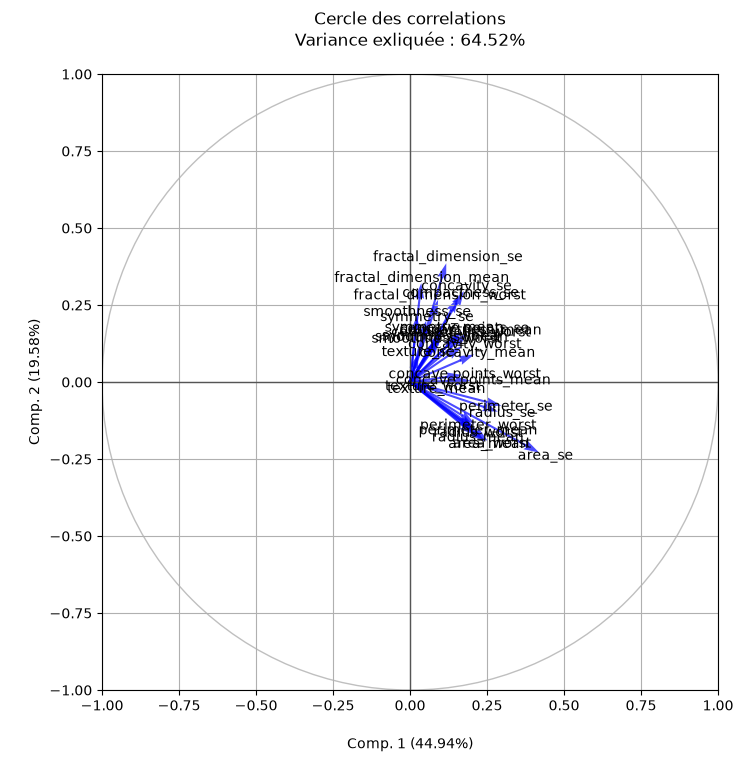

In [71]:
plot_correlation_circle(pca_no_target, [0, 1], X_eda.columns)

La composante 1 est la ligne droite imaginaire qui traverse le nuage de points là où il est le plus étalé. L'ACP cherche la direction dans laquelle les points sont le plus étirés / dispersés : l'algorithme prend le nuage de points global et fait pivoter une droite au centre de ce nuage. Il s'arrête là où la projection des points sur cette droite offre la plus grande dispersion (variance) possible (la taille globale des cellules).

La composante 2 est la direction perpendiculaire à la première qui capte le plus de variance restante (la forme / régularité).


1. Une redondance massive des 30 variables  
    - Toutes les flèches sont entassées dans le même quadrant droit (entre $-0{,}25$ et $+0{,}40$ sur l'axe $X$).
    - Les variables forment deux faisceaux ultra-compacts :
      - En bas à droite : le groupe taille/géométrie (area_*, perimeter_*, radius_*).
      - En haut à droite : le groupe forme/irrégularité (fractal_dimension_*, concavity_*, smoothness_*).  

    - Conclusion : Avoir 30 variables n'apporte presque pas d'information indépendante. La plupart d'entre elles mesurent la même chose.


2. Des variables très mal représentées sur ce plan
    - Aucune flèche ne s'approche du bord du cercle (norme $< 0{,}5$).
    - Cela signifie que le plan forme par PC1 et PC2 ne suffit pas à bien résumer individuellement chaque variable, bien qu'il capte $64{,}52\,\%$ de la variance totale.
  
  
3. L'interprétation des 2 premiers axes
    - Composante 1 ($44{,}94\,\%$) : Axe de la taille globale. Plus une tumeur est grande (area, perimeter, radius), plus elle se situe à droite.
    - Composante 2 ($19{,}58\,\%$) : Axe de la complexité / régularité. Plus la cellule a une forme complexe (fractal_dimension, concavity), plus elle monte vers le haut.

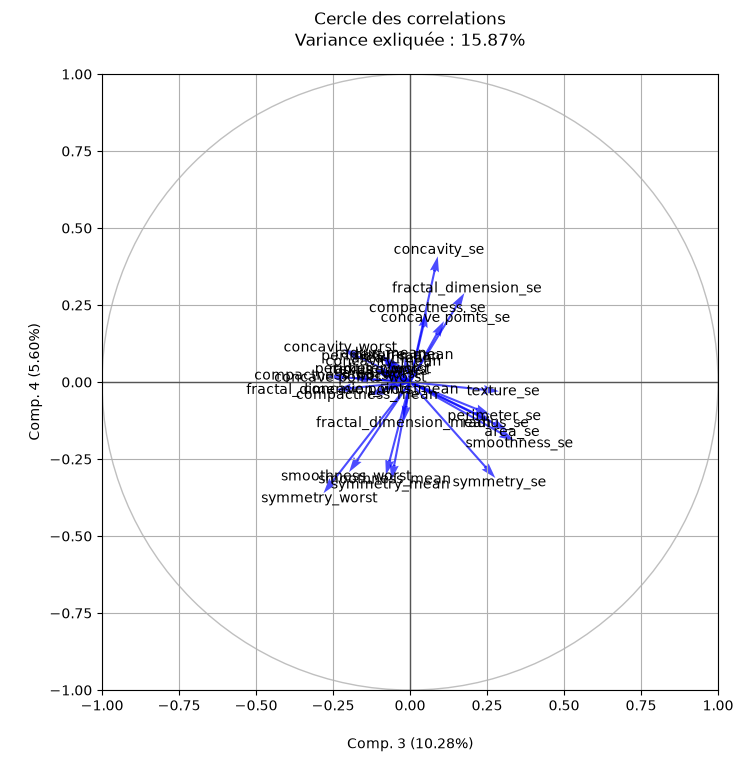

X_eda_scaled: (569, 30) | X_pca_no_target: (569, 30)


In [72]:
plot_correlation_circle(pca_no_target, [2, 3], X_eda.columns)
print(f"X_eda_scaled: {X_eda_scaled.shape} | X_pca_no_target: {X_pca_no_target.shape}")

La troisième composante capte un troisième axe d'information orthogonale (ici principalement les erreurs standards _se comme symmetry_se ou texture_se).
- Des flèches très courtes (norme $< 0{,}4$) : Les variables sont très peu corrélées avec les composantes 3 et 4.
- Du bruit et des variations secondaires : Les variables qui ressortent un peu plus ici sont presque toutes des erreurs de mesure (_se pour Standard Error, comme concavity_se ou symmetry_se).
  
  
Leur utilité est négligeable.